In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')

import numpy as np
import torch
import matplotlib.pyplot as plt

from tradinglab.data_feed import DataFeed
from tradinglab.features import build_pooled_sequences, FEATURE_NAMES, N_FEATURES

# Load all 34 stocks
feed = DataFeed.from_dir('data/egx')
print(f"Universe: {feed.n_assets} assets")
print(f"Period: {feed.dates[0].date()} → {feed.dates[-1].date()}")
print(f"Days: {feed.n_days}")
print(f"Features per stock: {N_FEATURES}")
print()

# Build SEQUENCES: window of past 5 days → predict day 6
SEQ_LEN = 5
split_day = int(feed.n_days * 0.7)

print("Building sequential dataset...")
X_train, y_train, X_test, y_test = build_pooled_sequences(feed, split_day, seq_len=SEQ_LEN)

print(f"Train sequences: {X_train.shape}  (samples × seq_len × features)")
print(f"Test sequences:  {X_test.shape}")
print()
print(f"Training samples:  {len(X_train)} (sequences from all 34 stocks)")
print(f"Test samples:      {len(X_test)} (sequences from all 34 stocks)")


Universe: 34 assets
Period: 2021-10-20 → 2026-07-30
Days: 1159
Features per stock: 9

Building sequential dataset...
Train sequences: (25509, 5, 9)  (samples × seq_len × features)
Test sequences:  (11286, 5, 9)

Training samples:  25509 (sequences from all 34 stocks)
Test samples:      11286 (sequences from all 34 stocks)


/Users/omarahmed/AI-projects/2026-carina/src/tradinglab/features.py:105: RuntimeWarning: invalid value encountered in divide
  return volume / avg20


In [2]:
from tradinglab.models import LSTMRegressor
from tradinglab.ml import train_model, predict

# Build LSTM: seq_len=5, 9 features → hidden=32 → 1 output
model = LSTMRegressor(n_features=N_FEATURES, hidden=32)

print("Model architecture:")
print(model)
print()
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print()

# Train on sequences
print("Training LSTM on pooled sequential data...")
history = train_model(model, X_train, y_train, X_test, y_test, epochs=200, lr=0.001)

print(f"\nFinal train loss: {history['train'][-1]:.6f}")
print(f"Final test loss:  {history['test'][-1]:.6f}")


Model architecture:
LSTMRegressor(
  (lstm): LSTM(9, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 5537

Training LSTM on pooled sequential data...

Final train loss: 0.000987
Final test loss:  0.000600


In [12]:
# LSTM strategy — rebalance every 10 days
class LSTMStrategyRebalance10:
    def __init__(self, model, feed, top_k=5, seq_len=5):
        self.model = model
        self.feed = feed
        self.top_k = top_k
        self.seq_len = seq_len
        self.day_count = 0
        self.current_weights = None

    def __call__(self, observation):
        self.day_count += 1

        # Rebalance every 10 days
        if self.day_count % 10 == 1:
            n_assets = observation.shape[0]
            seq_window = observation[:, -self.seq_len:, :]

            with torch.no_grad():
                X_torch = torch.as_tensor(seq_window, dtype=torch.float32)
                predictions = self.model(X_torch).numpy()

            # Allocate equally to top-5 stocks
            top_indices = np.argsort(predictions)[-self.top_k:]
            weights = np.zeros(n_assets)
            weights[top_indices] = 1.0 / self.top_k
            self.current_weights = weights

        return self.current_weights if self.current_weights is not None else np.zeros(34)

# Run backtest with commission
COMMISSION = 0.005

strategy = LSTMStrategyRebalance10(model, feed, top_k=5, seq_len=5)
sim = PortfolioSimulator(feed, benchmark="egx30", commission=COMMISSION)
result = run_backtest(sim, strategy, lookback=30, start=split_day)

portfolio_val = result['portfolio'] * 1000
equity = np.array(result['portfolio'])
rets = np.diff(equity) / equity[:-1]

print(f"LSTM Rebalance 10-day:")
print(f"Final value:  {portfolio_val[-1]:,.0f} EGP")
print(f"Total return: {total_return(rets):+.1%}")
print(f"Sharpe:       {sharpe(rets):.2f}")
print(f"Max drawdown: {max_drawdown(rets):.1%}")


LSTM Rebalance 10-day:
Final value:  1,186 EGP
Total return: +18.6%
Sharpe:       0.70
Max drawdown: 16.4%


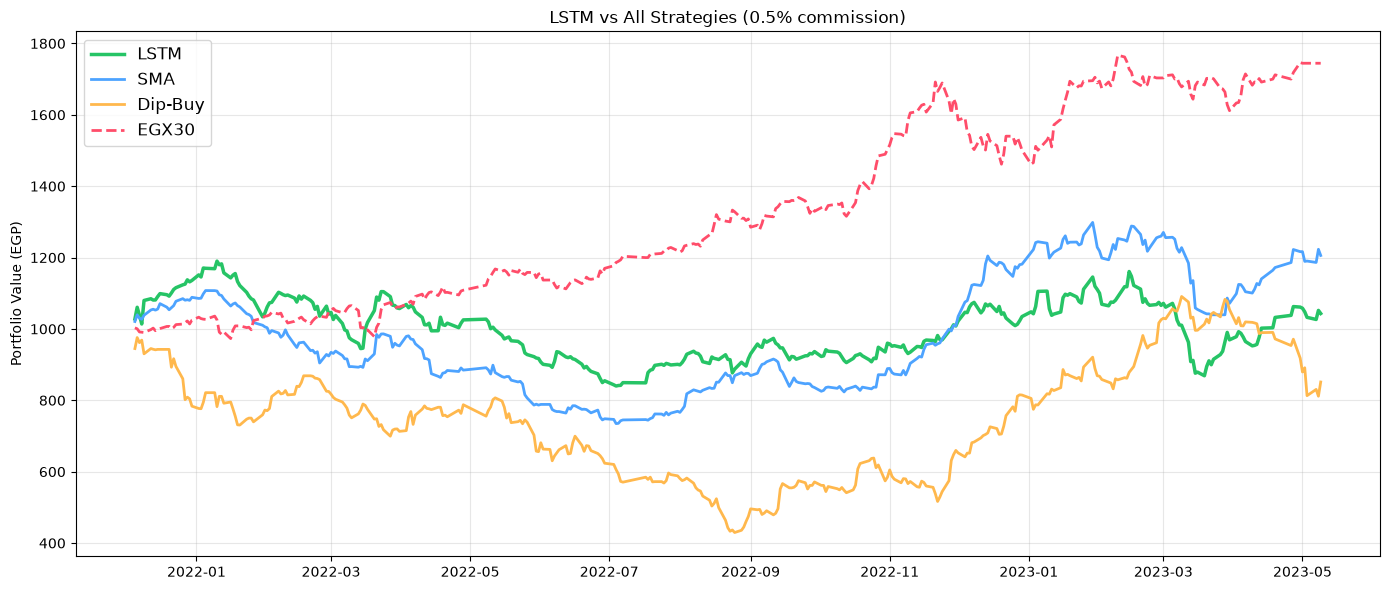


Final Values (truncated to same length):
LSTM:         1,043 EGP
SMA:          1,206 EGP
Dip-Buy:        851 EGP
EGX30:        1,745 EGP


In [13]:
from tradinglab.strategies.sma import sma_crossover_weights
from tradinglab.strategies.dip_buy import DipBuyStrategy

# Re-run strategies using SAME dates as LSTM
COMMISSION = 0.005

sim_sma = PortfolioSimulator(feed, benchmark="egx30", commission=COMMISSION)
result_sma = run_backtest(sim_sma, sma_crossover_weights, lookback=30)

sim_dip = PortfolioSimulator(feed, benchmark="egx30", commission=COMMISSION)
result_dip = run_backtest(sim_dip, DipBuyStrategy(), lookback=1)

# Use LSTM dates as reference (they're all the same length)
sma_port = result_sma['portfolio'] * 1000
dip_port = result_dip['portfolio'] * 1000
benchmark = result['benchmark'] * 1000

# Truncate all to same length
min_len = min(len(lstm_portfolio), len(sma_port), len(dip_port), len(benchmark))
lstm_p = lstm_portfolio[:min_len]
sma_p = sma_port[:min_len]
dip_p = dip_port[:min_len]
bench_p = benchmark[:min_len]
d = dates[:min_len]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(d, lstm_p,  label='LSTM',      linewidth=2.5, color='#26c466')
ax.plot(d, sma_p,   label='SMA',       linewidth=2, color='#4da3ff')
ax.plot(d, dip_p,   label='Dip-Buy',   linewidth=2, color='#ffb84d')
ax.plot(d, bench_p, label='EGX30',     linewidth=2, color='#ff4d6a', linestyle='--')
ax.set_ylabel('Portfolio Value (EGP)')
ax.set_title('LSTM vs All Strategies (0.5% commission)')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal Values (truncated to same length):")
print(f"LSTM:      {lstm_p[-1]:>8,.0f} EGP")
print(f"SMA:       {sma_p[-1]:>8,.0f} EGP")
print(f"Dip-Buy:   {dip_p[-1]:>8,.0f} EGP")
print(f"EGX30:     {bench_p[-1]:>8,.0f} EGP")


LSTM Rebalance 10-day:
Final value:  1,186 EGP
Total return: +18.6%
Sharpe:       0.70
Max drawdown: 16.4%
